Name:Malaika
23-Ntu-cs-1291
Lab4

Task No1 

In [1]:
#Importing Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load  dataset
print("Dataset Loaded Successfully")
wine = load_wine()
X, y = wine.data, wine.target

Dataset Loaded Successfully


In [3]:
# Dataset splitting into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


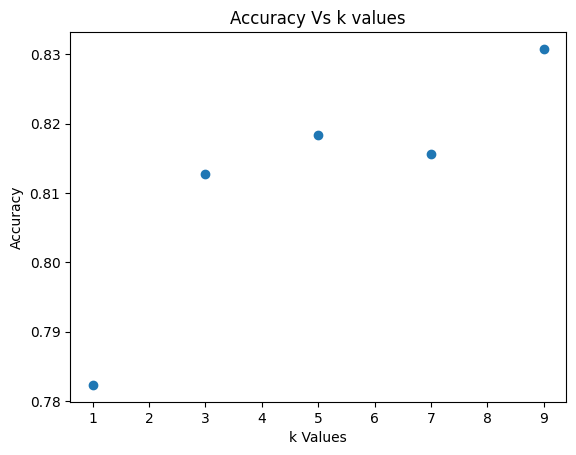

In [28]:
# Declare k values to test
values = [1, 3, 5, 7, 9]
# Train a KNN classifier for each value of k and evaluate  the accuracy scores
accuracy_scores = []
for k in values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    accuracy_scores.append(accuracy)
# Plot accuracy vs k values
plt.scatter(values, accuracy_scores)
plt.xlabel("k Values")
plt.ylabel("Accuracy")
plt.title("Accuracy Vs k values")
plt.show()
values = range(1, 30)
accuracy_scores = []

In [10]:
# Apply KNN  Algorithm
for k in values:
    model= KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

In [11]:
#Predict best value of k
k = values[accuracy_scores.index(max(accuracy_scores))]
print("Best value of k:", k)

Best value of k: 21


TASK NO 2(Change P vaues)


In [12]:
#Importing Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [13]:
# Load the Wine dataset
print("Dataset Loaded Successfully")
wine = load_wine()
X, y = wine.data, wine.target

Dataset Loaded Successfully


In [14]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Declare the p values 
p_values = [1, 2, 3, 4, 5]

In [16]:
# Train a KNN classifier for each value of p and evaluate the accuracy scores
accuracy_scores = []
for p in p_values:
    knn = KNeighborsClassifier(n_neighbors=5, p=p) 
    # Adjust n_neighbors as needed
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

In [17]:
# Print the accuracy scores for each p value
print("Accuracy scores for each p value:")
for p, accuracy in zip(p_values, accuracy_scores):
  print(f"p={p}: {accuracy}")
print()

Accuracy scores for each p value:
p=1: 0.8055555555555556
p=2: 0.7222222222222222
p=3: 0.7222222222222222
p=4: 0.7222222222222222
p=5: 0.7222222222222222



Task no3(SVM Algorithm)

In [18]:
#Import Libraries
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
warnings.filterwarnings("ignore")

In [19]:
print("Dataset Loaded Successfully")
df = pd.read_csv('income_evaluation.csv')
df.head()


Dataset Loaded Successfully


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [20]:
# Identification of  categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(exclude=['object']).columns


In [21]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [22]:
#Feature Selection
X = df.drop("income_ >50K", axis=1) 
y = df["income_ >50K"]

In [23]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [24]:
# Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [25]:
display(X_train.head())
svc = SVC(random_state=101)
svc.fit(X_train,y_train)
accuracies = cross_val_score(svc,X_train,y_train,cv=5)
print("Train Score:", np.mean(accuracies))
print("Test Score:", svc.score(X_test,y_test))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
4400,-0.996110,-0.550200,-1.222152,-0.147881,-0.221529,-2.351924,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2598,0.181302,-0.077999,-0.427479,-0.147881,-0.221529,0.791095,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
496,-1.364051,0.666475,-0.030143,-0.147881,-0.221529,-0.036015,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4915,-1.511228,-0.028649,-1.222152,-0.147881,-0.221529,-1.690236,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1341,1.358714,-0.955980,1.559203,-0.147881,-0.221529,-0.036015,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


Train Score: 0.8461355529131985
Test Score: 0.8488593155893536


In [26]:
grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],  # only fast, common kernels
    'gamma': ['scale', 'auto']    # use built-in gamma values
}


In [27]:

svm = SVC ()

svm_cv = GridSearchCV(svm, grid, cv = 5)
svm_cv.fit(X_train,y_train)
print("Best Parameters:",svm_cv.best_params_)
print("Train Score:",svm_cv.best_score_)
print("Test Score:",svm_cv.score(X_test,y_test))

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Train Score: 0.848038049940547
Test Score: 0.8479087452471483


ACTIVITY 1(Credit Card )

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

In [ ]:
#Dataset Loading
data = pd.read_csv("creditcard.csv")
data.head()

In [ ]:
data.dropna(inplace=True)
#Feature Selection
Y = data["Class"]
X = data.drop("Class", axis=1)

In [ ]:
#Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


In [ ]:
sm = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = sm.fit_resample(X_train, Y_train)
#Scaling of features
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)


In [ ]:
#Model Creation and evaluation
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5]}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1',
    cv=2,
    n_jobs=-1
)
grid.fit(X_train_resampled, Y_train_resampled)

In [ ]:
# Calculate Predictions
best = grid.best_estimator_
print("Best parameters:", grid.best_params_)
print("Best F1 score on CV:", grid.best_score_)
Y_pred = best_knn.predict(X_test)

In [ ]:
#Accuracy Score
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

print("Test Set Metrics:")
print("Accuracy:", accuracy)
print("F1-Score:", f1)
print("Confusion Matrix:", cm)